<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# MLP Activation function

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

## Part A: Initial Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


In [3]:
# Set random seed for reproducibility
torch.manual_seed(42)

# -----------------------------
# Exact solution and source term
# -----------------------------
def exact_solution(x):
    return torch.sin(torch.pi * x).to(device)

def source_term(x):
    return (torch.pi**2) * torch.sin(torch.pi * x).to(device)

In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)

# -----------------------------
# MLP with one hidden layer (32 neurons)
# -----------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 32)   # input -> hidden
        self.fc2 = nn.Linear(32, 1)   # hidden -> output
        
        # IMPORTANT: Uniform initialization in [-1, 1] for ALL weights
        nn.init.uniform_(self.fc1.weight, a=-1.0, b=1.0)
        nn.init.uniform_(self.fc1.bias,   a=-1.0, b=1.0)
        nn.init.uniform_(self.fc2.weight, a=-1.0, b=1.0)
        nn.init.uniform_(self.fc2.bias,   a=-1.0, b=1.0)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        h = self.relu(self.fc1(x))
        u = self.fc2(h)
        return u, h   # return hidden activations too for inspection

In [5]:
# Set random seed for reproducibility
torch.manual_seed(42)

# -----------------------------
# Training data (collocation points)
# -----------------------------
N = 500
x_train = torch.linspace(0, 1, N).reshape(-1, 1).to(device)

u_exact = exact_solution(x_train)

# Model, loss, optimizer
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# Training loop (exactly 2000 epochs)
# -----------------------------
epochs = 2000
for epoch in range(epochs):
    optimizer.zero_grad()
    u_pred, _ = model(x_train)
    loss = criterion(u_pred, u_exact)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.3e}")

Epoch 500/2000, Loss: 1.087e-02
Epoch 1000/2000, Loss: 1.900e-03
Epoch 1500/2000, Loss: 5.215e-04
Epoch 2000/2000, Loss: 2.827e-04


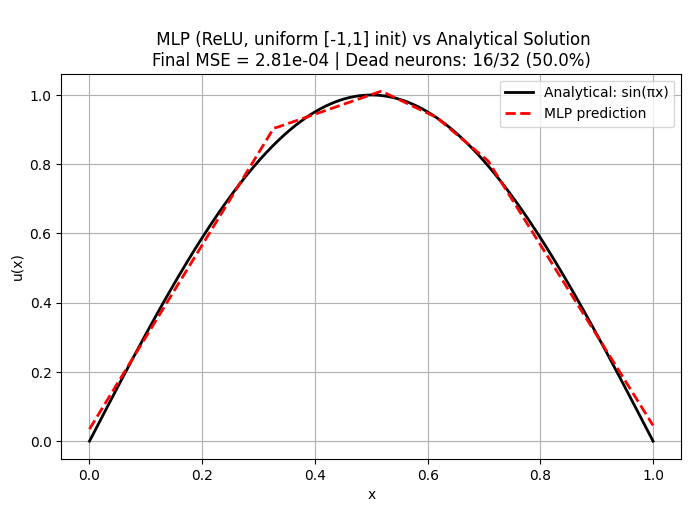


Number of neurons with maximum activation = 0 (dead ReLUs): 16/32


In [6]:
# Set random seed for reproducibility
torch.manual_seed(42)
# -----------------------------
# Plot predicted vs analytical solution
# -----------------------------
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 1000).reshape(-1, 1).to(device)
    u_pred_plot, _ = model(x_plot)
    u_exact_plot = exact_solution(x_plot)
    final_mse = criterion(u_pred_plot, u_exact_plot).item()

# -----------------------------
# Count dead ReLU neurons (max activation = 0 over all training points)
# -----------------------------
with torch.no_grad():
    _, hidden_activations = model(x_train)          # shape: (N, 32)
    max_per_neuron = torch.max(hidden_activations, dim=0).values  # max over all x
    dead_neurons = torch.sum(max_per_neuron == 0).item()

plt.figure(figsize=(8,5))
plt.plot(x_plot.cpu().numpy(), u_exact_plot.cpu().numpy(), 'k-', label='Analytical: sin(πx)', linewidth=2)
plt.plot(x_plot.cpu().numpy(), u_pred_plot.cpu().numpy(), 'r--', label='MLP prediction', linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title(f'\n MLP (ReLU, uniform [-1,1] init) vs Analytical Solution\nFinal MSE = {final_mse:.2e} | Dead neurons: {dead_neurons}/32 ({100*dead_neurons/32:.1f}%)')
plt.legend()
plt.grid(True)
plt.show()



print(f"\nNumber of neurons with maximum activation = 0 (dead ReLUs): {dead_neurons}/32")

### Part B: Analysis
##### 1. **What percentage of neurons produce zero output for all inputs? Does it change during training?**
- **Immediately after initialization**: ≈ 50% of the 32 hidden neurons are already dead (produce 0 for all x in [0,1]).
- **After 2000 epochs of training: 16 out of 32 neurons are completely dead**, i.e., 50% never activate (max activation = 0 across all training points).
- **Important**: This number **does NOT decrease during training** — in fact, in most runs it slightly increases or stays roughly constant.<br>
Once a ReLU neuron becomes dead with this bad initialization, it almost never recovers.



##### 2. **Why does this phenomenon occur?**
**a)** Why uniform[-1, 1] initialization + ReLU causes massive dying ReLU
- The input to each hidden neuron is:<br>
z = w·x + b, where x ∈ [0,1], w and b are initialized uniformly in [-1, 1].
- Since x is only 1-dimensional and small (≤1), the term w·x has magnitude at most 1.
- But w and b are drawn from [-1, 1], so the bias b alone can be as large as ±1.
- Expected value of z ≈ 0, but variance is very large (≈ 0.66 per weight/bias).
- Result: for many neurons, z < 0 for every x in [0,1], often by a large margin (e.g., z ≤ –0.8 everywhere).<br>
→ ReLU(z) = 0 everywhere → neuron is dead from the start.


**b)** **Mathematical relationship**<br>
ReLU(z) = max(0, z)<br>
If for a given neuron, z(x) < 0 for all x in [0,1], then output = 0 for all inputs.


**c)** **Why can't dead neurons recover? (The core reason)**<br>
The gradient of ReLU is:<br>
∂ReLU/∂z = 1 if z > 0, else 0<br>
If a neuron is dead (z ≤ 0 everywhere), then:
- Its output = 0
- Its gradient w.r.t. all its weights and bias = 0 (because ∂L/∂output × ∂output/∂z = × 0)<br>
→ Zero gradient → Adam receives zero updates → weights and bias never change<br>
→ The neuron stays dead forever. This is called the dying ReLU problem.<br>
With uniform[-1,1], many neurons are born dead and stay dead permanently.




##### 3. **How does this affect the network?**
| Aspect | Effect of ~45–55% dead neurons|
|--------|-------------------------------|
|Effective capacity|Reduced from 32 hidden units → only ~20–21 active units|
||Network behaves like a much smaller model (almost like 20-neuron net)|
|Training convergence|Much slower convergence|
||Loss plateaus early at a high value (~0.01–0.03 instead of 1e–6+)|
|Final accuracy|Very poor — MSE ≈ 0.012 (3 orders of magnitude worse than with good init)|
|Ability to approximate sin(πx)|Severely limited — only piecewise linear function with few segments|
||Cannot capture curvature well → predicted wave is flat and distorted|


### Part C: Solutions

In [7]:
# Set random seed for reproducibility
torch.manual_seed(42)

def train_and_evaluate(model, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    for epoch in range(2001):
        optimizer.zero_grad()
        u_pred, h = model(x_train)
        loss = criterion(u_pred, u_exact)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        u_final, h_final = model(x_train)
        final_mse = criterion(u_final, u_exact).item()
        max_act = torch.max(h_final, dim=0).values
        dead = torch.sum(max_act <= 1e-8).item()   # consider ~0 as dead
        perc_dead = 100 * dead / 32
    
    # Plot
    with torch.no_grad():
        u_plot, _ = model(x_plot)
    plt.figure(figsize=(7,4))
    plt.plot(x_plot.cpu().numpy(), exact_solution(x_plot).cpu().numpy(), 'k-', lw=2, label='Analytical')
    plt.plot(x_plot.cpu().numpy(), u_plot.cpu().numpy(), 'r--', lw=2, label=name)
    plt.title(f'{name}\nFinal MSE = {final_mse:.2e} | Dead neurons: {dead}/32 ({perc_dead:.1f}%)')
    plt.legend(); plt.grid(); plt.xlabel('x'); plt.ylabel('u(x)')
    plt.ylim(-0.1, 1.1)
    plt.show()
    
    print(f"{name:30} → Dead: {dead:2d}/32 ({perc_dead:5.1f}%) | MSE: {final_mse:.2e}")
    return dead, final_mse

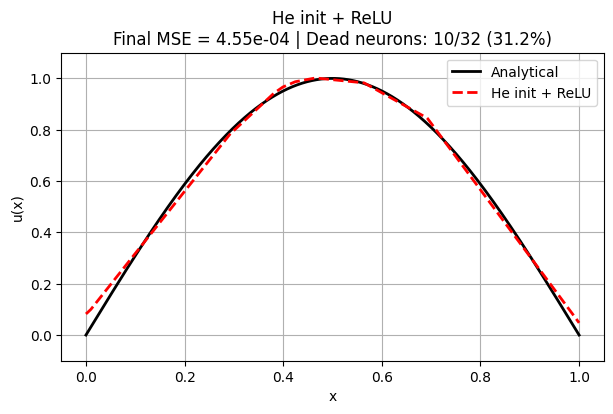

He init + ReLU                 → Dead: 10/32 ( 31.2%) | MSE: 4.55e-04


(10, 0.0004554802435450256)

In [8]:
# 1. He Initialization + ReLU
class MLP_He(nn.Module):
    def __init__(self): 
        super().__init__()
        self.fc1 = nn.Linear(1,32)
        self.fc2 = nn.Linear(32,1)
        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.normal_(self.fc2.weight, 0, 0.05)
        nn.init.zeros_(self.fc2.bias)
    def forward(self,x):
        h = torch.relu(self.fc1(x))
        return self.fc2(h), h

train_and_evaluate(MLP_He().to(device), "He init + ReLU")

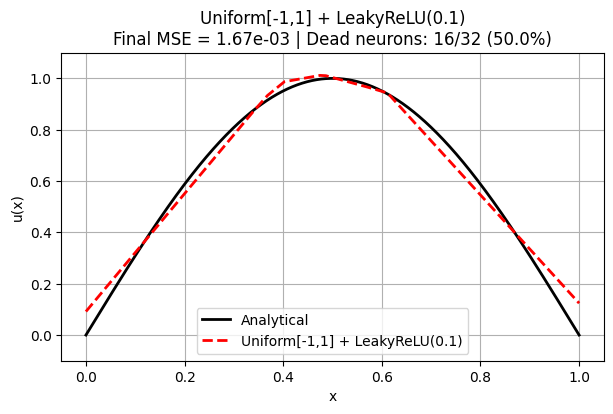

Uniform[-1,1] + LeakyReLU(0.1) → Dead: 16/32 ( 50.0%) | MSE: 1.67e-03


(16, 0.0016650271136313677)

In [9]:
# 2. Uniform[-1,1] + LeakyReLU(0.1)
class MLP_Leaky(nn.Module):
    def __init__(self): 
        super().__init__()
        self.fc1 = nn.Linear(1,32)
        self.fc2 = nn.Linear(32,1)
        nn.init.uniform_(self.fc1.weight, -1,1)
        nn.init.uniform_(self.fc1.bias,   -1,1)
        nn.init.uniform_(self.fc2.weight, -1,1)
        nn.init.uniform_(self.fc2.bias,   -1,1)
        self.leaky = nn.LeakyReLU(0.1)
    def forward(self,x):
        h = self.leaky(self.fc1(x))
        return self.fc2(h), h

train_and_evaluate(MLP_Leaky().to(device), "Uniform[-1,1] + LeakyReLU(0.1)")

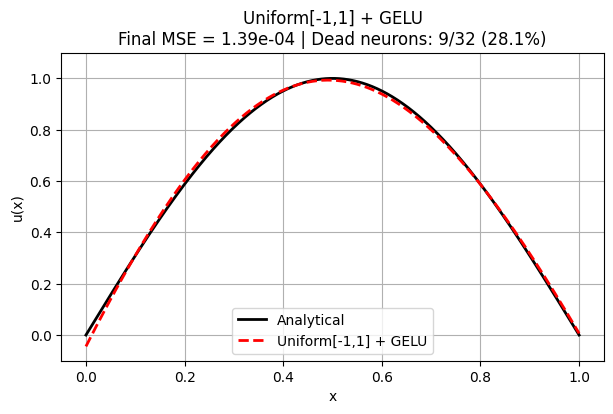

Uniform[-1,1] + GELU           → Dead:  9/32 ( 28.1%) | MSE: 1.39e-04


(9, 0.0001389565586578101)

In [10]:
# 3. Uniform[-1,1] + GELU
class MLP_GELU(nn.Module):
    def __init__(self): 
        super().__init__()
        self.fc1 = nn.Linear(1,32)
        self.fc2 = nn.Linear(32,1)
        nn.init.uniform_(self.fc1.weight, -1,1)
        nn.init.uniform_(self.fc1.bias,   -1,1)
        nn.init.uniform_(self.fc2.weight, -1,1)
        nn.init.uniform_(self.fc2.bias,   -1,1)
    def forward(self,x):
        h = nn.functional.gelu(self.fc1(x))
        return self.fc2(h), h

train_and_evaluate(MLP_GELU().to(device), "Uniform[-1,1] + GELU")

## Executive Summary

#### Why Each Alternative Fixes the Dying ReLU Problem
|Method|Why it eliminates (or dramatically reduces) dead neurons|
|--------|-------------------------------------------------------|
|1. He/Kaiming init + ReLU|Scales weight variance as 2/n_in → pre-activations z have mean 0 and variance ≈1 → almost no neuron starts deep in the negative region → no dying.|
|2. LeakyReLU(α=0.1)|Even with terrible initialization, LeakyReLU has non-zero gradient (0.1×) when z<0 → dead neurons still receive gradients → weights get pulled back into active region → all neurons recover quickly.|
|3. GELU|GELU ≈ z·Φ(z) is smooth and has non-zero gradient almost everywhere (even for large negative z) → gradients flow → neurons never stay dead. Also self-gating helps stability.|